# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Untuk Machine Learning (Preprocessing & Splitting)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset
df = pd.read_csv('../dataset_raw/diabetes.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


--- Statistik Deskriptif ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


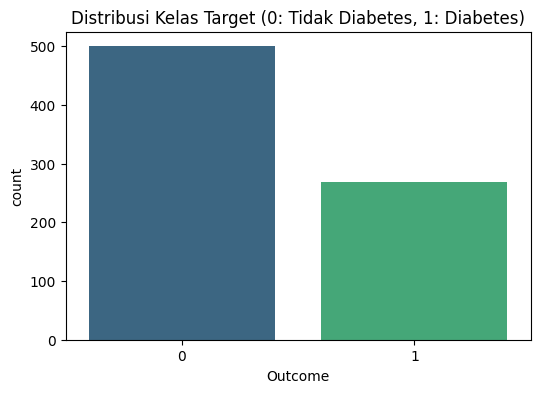

--- Jumlah nilai 0 yang tidak masuk akal (Missing Values) ---
Glucose: 5 baris
BloodPressure: 35 baris
SkinThickness: 227 baris
Insulin: 374 baris
BMI: 11 baris


In [3]:
# 1. Melihat informasi tipe data dan ketiadaan nilai Null standar
print("--- Informasi Dataset ---")
df.info()
print("\n")

# 2. Melihat statistik deskriptif
print("--- Statistik Deskriptif ---")
display(df.describe())

# 3. Visualisasi distribusi kelas target (Outcome)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribusi Kelas Target (0: Tidak Diabetes, 1: Diabetes)')
plt.show()

# 4. IDENTIFIKASI MASALAH (Penting untuk dataset ini!)
# Secara medis, nilai Glucose, BloodPressure, SkinThickness, Insulin, dan BMI tidak mungkin 0.
# Nilai 0 di sini sebenarnya adalah 'Missing Value' (data yang hilang).
kolom_medis = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("--- Jumlah nilai 0 yang tidak masuk akal (Missing Values) ---")
for col in kolom_medis:
    print(f"{col}: {len(df[df[col] == 0])} baris")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Menangani Missing Value (Mengubah 0 menjadi NaN, lalu mengisi dengan nilai Median)
kolom_medis = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Ganti 0 dengan NaN
df[kolom_medis] = df[kolom_medis].replace(0, np.nan)

# Imputasi dengan median (median lebih kebal terhadap outlier/pencilan dibandingkan mean)
for col in kolom_medis:
    df[col] = df[col].fillna(df[col].median())

print("Pengecekan jumlah missing value setelah imputasi:")
print(df.isnull().sum())
print("-" * 30)

# 2. Memisahkan Fitur (X) dan Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 3. Train-Test Split (Membagi data latih 80% dan data uji 20%)
# stratify=y digunakan agar proporsi kelas 0 dan 1 tetap seimbang di data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")
print("-" * 30)

# 4. Standarisasi Fitur (Feature Scaling)
# Mengubah skala data agar memiliki rata-rata 0 dan standar deviasi 1
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# Untuk data test, KITA HANYA MENGGUNAKAN transform() untuk mencegah Data Leakage!
X_test_scaled = scaler.transform(X_test)

# Mengubah kembali menjadi DataFrame (opsional, agar lebih mudah dilihat/disimpan)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Tampilan 5 baris pertama data latih setelah di-scaling:")
display(X_train_scaled_df.head())

Pengecekan jumlah missing value setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
------------------------------
Jumlah data latih: 614
Jumlah data uji: 154
------------------------------
Tampilan 5 baris pertama data latih setelah di-scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320


# **6. Menyimpan Dataset Hasil Preprocessing**

Dataset yang sudah melalui tahap pembersihan (penanganan missing value) disimpan sebagai file CSV baru. File inilah yang akan digunakan pada tahap modelling (Kriteria 2), bukan dataset raw.

In [5]:
import os

output_path = 'dataset_preprocessing.csv'
df.to_csv(output_path, index=False)

print(f"Dataset hasil preprocessing berhasil disimpan di: {os.path.abspath(output_path)}")
print(f"Ukuran dataset hasil preprocessing: {df.shape}")
display(df.head())

Dataset hasil preprocessing berhasil disimpan di: /home/claude/build/Eksperimen_SML_Ahmaddani/preprocessing/dataset_preprocessing.csv
Ukuran dataset hasil preprocessing: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
